In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\heart\quantum_6g_ai")
RESULTS_DIR = PROJECT_ROOT / "results"

TRAIN_Q_PATH = RESULTS_DIR / "quantum_train_features.csv"
TEST_Q_PATH = RESULTS_DIR / "quantum_test_features.csv"

# ---------------------------------------------------------
# Load datasets
# ---------------------------------------------------------

train_q = pd.read_csv(TRAIN_Q_PATH)
test_q = pd.read_csv(TEST_Q_PATH)

QUANTUM_FEATURES = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

TARGET_COLUMN = "Label"

X_train_q = train_q[QUANTUM_FEATURES].to_numpy(
    dtype=float
)

X_test_q = test_q[QUANTUM_FEATURES].to_numpy(
    dtype=float
)

y_train = train_q[TARGET_COLUMN].to_numpy(
    dtype=int
)

y_test = test_q[TARGET_COLUMN].to_numpy(
    dtype=int
)

print("=" * 60)
print("VQC TRAINING DATA")
print("=" * 60)

print("Training features:", X_train_q.shape)
print("Testing features :", X_test_q.shape)

print("Training labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting labels:")
print(pd.Series(y_test).value_counts().sort_index())

VQC TRAINING DATA
Training features: (800, 4)
Testing features : (200, 4)
Training labels:
0    400
1    400
Name: count, dtype: int64

Testing labels:
0    100
1    100
Name: count, dtype: int64


In [2]:
N_QUBITS = 4
N_LAYERS = 2

theta = ParameterVector(
    "θ",
    length=N_QUBITS * 2 * N_LAYERS
)

print("Number of qubits        :", N_QUBITS)
print("Number of VQC layers    :", N_LAYERS)
print("Number of parameters    :", len(theta))
print("Parameters:")
print(list(theta))

Number of qubits        : 4
Number of VQC layers    : 2
Number of parameters    : 16
Parameters:
[ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15])]


In [3]:
def build_vqc_ansatz(
    n_qubits=4,
    n_layers=2
):
    """
    Build the trainable variational ansatz.

    Each layer:
        Ry(theta)
        Rz(theta)
        Linear CNOT entanglement
    """

    qc = QuantumCircuit(n_qubits)

    parameter_index = 0

    for layer in range(n_layers):

        # Trainable single-qubit rotations
        for qubit in range(n_qubits):

            qc.ry(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

            qc.rz(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

        # Linear entanglement
        for qubit in range(n_qubits - 1):
            qc.cx(
                qubit,
                qubit + 1
            )

    return qc


ansatz = build_vqc_ansatz(
    N_QUBITS,
    N_LAYERS
)

print(ansatz.draw("text"))

     ┌──────────┐┌──────────┐     ┌──────────┐ ┌──────────┐             »
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├──■──┤ Ry(θ[8]) ├─┤ Rz(θ[9]) ├─────────────»
     ├──────────┤├──────────┤┌─┴─┐└──────────┘┌┴──────────┤┌───────────┐»
q_1: ┤ Ry(θ[2]) ├┤ Rz(θ[3]) ├┤ X ├─────■──────┤ Ry(θ[10]) ├┤ Rz(θ[11]) ├»
     ├──────────┤├──────────┤└───┘   ┌─┴─┐    └───────────┘├───────────┤»
q_2: ┤ Ry(θ[4]) ├┤ Rz(θ[5]) ├────────┤ X ├──────────■──────┤ Ry(θ[12]) ├»
     ├──────────┤├──────────┤        └───┘        ┌─┴─┐    ├───────────┤»
q_3: ┤ Ry(θ[6]) ├┤ Rz(θ[7]) ├─────────────────────┤ X ├────┤ Ry(θ[14]) ├»
     └──────────┘└──────────┘                     └───┘    └───────────┘»
«                            
«q_0: ──────■────────────────
«         ┌─┴─┐              
«q_1: ────┤ X ├──────■───────
«     ┌───┴───┴───┐┌─┴─┐     
«q_2: ┤ Rz(θ[13]) ├┤ X ├──■──
«     ├───────────┤└───┘┌─┴─┐
«q_3: ┤ Rz(θ[15]) ├─────┤ X ├
«     └───────────┘     └───┘


In [4]:
print("=" * 60)
print("VARIATIONAL ANSATZ VALIDATION")
print("=" * 60)

print("Qubits       :", ansatz.num_qubits)
print("Depth        :", ansatz.depth())
print("Parameters   :", len(ansatz.parameters))
print("Gate counts  :", ansatz.count_ops())

assert ansatz.num_qubits == 4
assert len(ansatz.parameters) == 16

print("\nValidation: PASS")

VARIATIONAL ANSATZ VALIDATION
Qubits       : 4
Depth        : 9
Parameters   : 16
Gate counts  : OrderedDict([('ry', 8), ('rz', 8), ('cx', 6)])

Validation: PASS


In [5]:
def build_vqc(
    feature_angles,
    n_qubits=4,
    n_layers=2
):
    """
    Complete parameterized VQC.

    Part 1:
        Classical feature encoding
        Ry(x) + Rz(x)

    Part 2:
        Linear CNOT entanglement

    Part 3:
        Trainable variational layers
        Ry(theta) + Rz(theta)
        + CNOT entanglement
    """

    qc = QuantumCircuit(n_qubits)

    # -----------------------------------------------------
    # Feature encoding
    # -----------------------------------------------------

    for qubit, angle in enumerate(feature_angles):
        qc.ry(angle, qubit)
        qc.rz(angle, qubit)

    # Feature-map entanglement
    for qubit in range(n_qubits - 1):
        qc.cx(qubit, qubit + 1)

    # -----------------------------------------------------
    # Variational layers
    # -----------------------------------------------------

    parameter_index = 0

    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qc.ry(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

            qc.rz(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

        # Variational entanglement
        for qubit in range(n_qubits - 1):
            qc.cx(qubit, qubit + 1)

    return qc

In [6]:
sample_angles = X_train_q[0]

vqc = build_vqc(
    sample_angles,
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
)

print(vqc.draw("text"))

     ┌─────────────┐ ┌─────────────┐      ┌──────────┐┌──────────┐            »
q_0: ┤ Ry(0.73731) ├─┤ Rz(0.73731) ├───■──┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├────────────»
     ├─────────────┴┐├─────────────┴┐┌─┴─┐└──────────┘├──────────┤┌──────────┐»
q_1: ┤ Ry(-0.73731) ├┤ Rz(-0.73731) ├┤ X ├─────■──────┤ Ry(θ[2]) ├┤ Rz(θ[3]) ├»
     ├──────────────┤├──────────────┤└───┘   ┌─┴─┐    └──────────┘├──────────┤»
q_2: ┤ Ry(-0.33427) ├┤ Rz(-0.33427) ├────────┤ X ├─────────■──────┤ Ry(θ[4]) ├»
     └┬────────────┬┘└┬────────────┬┘        └───┘       ┌─┴─┐    ├──────────┤»
q_3: ─┤ Ry(1.2797) ├──┤ Rz(1.2797) ├─────────────────────┤ X ├────┤ Ry(θ[6]) ├»
      └────────────┘  └────────────┘                     └───┘    └──────────┘»
«                 ┌──────────┐ ┌──────────┐                                    
«q_0: ─────■──────┤ Ry(θ[8]) ├─┤ Rz(θ[9]) ├───────────────────■────────────────
«        ┌─┴─┐    └──────────┘┌┴──────────┤┌───────────┐    ┌─┴─┐              
«q_1: ───┤ X ├─────────■──────┤ Ry(θ[10]

In [8]:
print("=" * 60)
print("COMPLETE VQC VALIDATION")
print("=" * 60)

print("Qubits      :", vqc.num_qubits)
print("Depth       :", vqc.depth())
print("Parameters  :", len(vqc.parameters))
print("Gate counts :", vqc.count_ops())

assert vqc.num_qubits == 4
assert len(vqc.parameters) == 16

print("\nValidation: PASS")

COMPLETE VQC VALIDATION
Qubits      : 4
Depth       : 13
Parameters  : 16
Gate counts : OrderedDict([('ry', 12), ('rz', 12), ('cx', 9)])

Validation: PASS


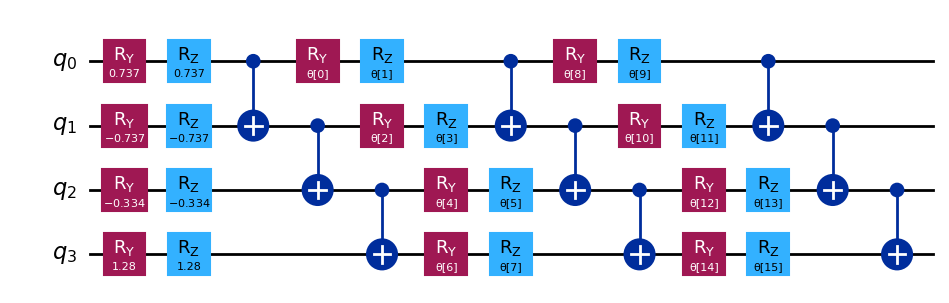

In [9]:
vqc.draw("mpl")

In [10]:
print(vqc.draw("text"))

     ┌─────────────┐ ┌─────────────┐      ┌──────────┐┌──────────┐            »
q_0: ┤ Ry(0.73731) ├─┤ Rz(0.73731) ├───■──┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├────────────»
     ├─────────────┴┐├─────────────┴┐┌─┴─┐└──────────┘├──────────┤┌──────────┐»
q_1: ┤ Ry(-0.73731) ├┤ Rz(-0.73731) ├┤ X ├─────■──────┤ Ry(θ[2]) ├┤ Rz(θ[3]) ├»
     ├──────────────┤├──────────────┤└───┘   ┌─┴─┐    └──────────┘├──────────┤»
q_2: ┤ Ry(-0.33427) ├┤ Rz(-0.33427) ├────────┤ X ├─────────■──────┤ Ry(θ[4]) ├»
     └┬────────────┬┘└┬────────────┬┘        └───┘       ┌─┴─┐    ├──────────┤»
q_3: ─┤ Ry(1.2797) ├──┤ Rz(1.2797) ├─────────────────────┤ X ├────┤ Ry(θ[6]) ├»
      └────────────┘  └────────────┘                     └───┘    └──────────┘»
«                 ┌──────────┐ ┌──────────┐                                    
«q_0: ─────■──────┤ Ry(θ[8]) ├─┤ Rz(θ[9]) ├───────────────────■────────────────
«        ┌─┴─┐    └──────────┘┌┴──────────┤┌───────────┐    ┌─┴─┐              
«q_1: ───┤ X ├─────────■──────┤ Ry(θ[10]

In [11]:
try:
    import qiskit_aer
    print("Qiskit Aer:", qiskit_aer.__version__)
    print("Aer import: OK")
except Exception as e:
    print("Aer import failed:")
    print(e)

Qiskit Aer: 0.17.2
Aer import: OK


In [12]:
# ============================================================
# IDEAL VQC FORWARD PASS TEST
# ============================================================

import numpy as np
from qiskit_aer import AerSimulator
from qiskit import transpile

print("=" * 60)
print("IDEAL VQC FORWARD PASS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Aer simulator
# ------------------------------------------------------------
simulator = AerSimulator()

# ------------------------------------------------------------
# 2. Test parameter values
# ------------------------------------------------------------
rng = np.random.default_rng(42)

initial_theta = rng.uniform(
    -0.1,
    0.1,
    size=len(theta)
)

print("Simulator          :", simulator.name)
print("Number of qubits   :", N_QUBITS)
print("Number of layers   :", N_LAYERS)
print("Trainable params   :", len(initial_theta))

# ------------------------------------------------------------
# 3. Build one VQC
# ------------------------------------------------------------
sample_angles = X_train_q[0]

vqc = build_vqc(
    sample_angles,
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
)

# Bind parameters
parameter_values = {
    theta[i]: initial_theta[i]
    for i in range(len(theta))
}

bound_vqc = vqc.assign_parameters(parameter_values)

# ------------------------------------------------------------
# 4. Add measurement
# ------------------------------------------------------------
measured = bound_vqc.copy()
measured.measure_all()

# ------------------------------------------------------------
# 5. Transpile for Aer
# ------------------------------------------------------------
compiled = transpile(
    measured,
    simulator,
    optimization_level=1
)

# ------------------------------------------------------------
# 6. Run ideal simulation
# ------------------------------------------------------------
shots = 4096

job = simulator.run(
    compiled,
    shots=shots,
    seed_simulator=42
)

result = job.result()
counts = result.get_counts()

# ------------------------------------------------------------
# 7. Convert counts → probabilities
# ------------------------------------------------------------
p0 = 0.0
p1 = 0.0

for bitstring, count in counts.items():

    # Qiskit bitstrings are displayed as c3 c2 c1 c0.
    # Right-most bit corresponds to q0.
    q0_bit = int(bitstring[-1])

    if q0_bit == 0:
        p0 += count / shots
    else:
        p1 += count / shots

# ------------------------------------------------------------
# 8. Calculate Z expectation
# ------------------------------------------------------------
z_expectation = p0 - p1

# ------------------------------------------------------------
# 9. Binary classification probability
# ------------------------------------------------------------
probability_class_1 = (1.0 - z_expectation) / 2.0

prediction = int(probability_class_1 >= 0.5)

# ------------------------------------------------------------
# 10. Display
# ------------------------------------------------------------
print("\nMeasurement counts:")
print(counts)

print("\nProbability q0 = 0 :", round(p0, 6))
print("Probability q0 = 1 :", round(p1, 6))

print("\n<Z0>              :", round(z_expectation, 6))
print("P(y=1)            :", round(probability_class_1, 6))
print("Prediction        :", prediction)

print("\nCheck probability sum:")
print("P0 + P1           :", round(p0 + p1, 6))

assert abs((p0 + p1) - 1.0) < 1e-9
assert -1.0 <= z_expectation <= 1.0
assert 0.0 <= probability_class_1 <= 1.0

print("\nValidation: PASS")

IDEAL VQC FORWARD PASS
Simulator          : aer_simulator
Number of qubits   : 4
Number of layers   : 2
Trainable params   : 16

Measurement counts:
{'0000': 1873, '1000': 1136, '1100': 36, '0011': 316, '1110': 167, '1011': 152, '1111': 24, '0110': 314, '0100': 26, '0101': 17, '1101': 11, '1001': 3, '0111': 6, '1010': 8, '0010': 5, '0001': 2}

Probability q0 = 0 : 0.870361
Probability q0 = 1 : 0.129639

<Z0>              : 0.740723
P(y=1)            : 0.129639
Prediction        : 0

Check probability sum:
P0 + P1           : 1.0

Validation: PASS


In [13]:
# ============================================================
# IDEAL VQC TRAINING
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from qiskit_aer import AerSimulator
from qiskit import transpile
from scipy.optimize import minimize

print("=" * 60)
print("IDEAL VQC TRAINING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SHOTS = 1024
MAXITER = 60
SEED = 42

rng = np.random.default_rng(SEED)

simulator = AerSimulator()

print("Simulator          :", simulator.name)
print("Training samples   :", len(X_train_q))
print("Test samples       :", len(X_test_q))
print("Qubits             :", N_QUBITS)
print("VQC layers         :", N_LAYERS)
print("Parameters         :", len(theta))
print("Shots              :", SHOTS)
print("Max iterations     :", MAXITER)

# ------------------------------------------------------------
# 2. Loss function
# ------------------------------------------------------------

def binary_cross_entropy(y_true, y_prob):
    """
    Binary Cross-Entropy loss.
    """
    
    eps = 1e-10
    
    y_prob = np.clip(
        np.asarray(y_prob, dtype=float),
        eps,
        1.0 - eps
    )
    
    y_true = np.asarray(y_true, dtype=float)
    
    return -np.mean(
        y_true * np.log(y_prob)
        + (1.0 - y_true) * np.log(1.0 - y_prob)
    )


# ------------------------------------------------------------
# 3. Single-sample VQC prediction
# ------------------------------------------------------------

def vqc_probability(
    feature_angles,
    parameter_values,
    shots=1024,
    seed=42
):
    """
    Run one VQC sample on an ideal Aer simulator
    and return P(y=1).
    """
    
    # Build VQC
    circuit = build_vqc(
        feature_angles,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS
    )
    
    # Bind theta parameters
    parameter_dict = {
        theta[i]: parameter_values[i]
        for i in range(len(parameter_values))
    }
    
    circuit = circuit.assign_parameters(parameter_dict)
    
    # Measurement
    circuit.measure_all()
    
    # Compile
    compiled = transpile(
        circuit,
        simulator,
        optimization_level=1
    )
    
    # Run
    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )
    
    result = job.result()
    counts = result.get_counts()
    
    # q0 probability
    p1 = 0.0
    
    for bitstring, count in counts.items():
        
        q0_bit = int(bitstring[-1])
        
        if q0_bit == 1:
            p1 += count / shots
    
    return p1


# ------------------------------------------------------------
# 4. Batch prediction
# ------------------------------------------------------------

def vqc_predict_proba(
    X_data,
    parameter_values,
    shots=1024,
    seed=42
):
    """
    Generate P(y=1) for every sample.
    """
    
    probabilities = []
    
    for i, feature_angles in enumerate(X_data):
        
        # Use deterministic but different seed per sample
        sample_seed = seed + i
        
        p1 = vqc_probability(
            feature_angles,
            parameter_values,
            shots=shots,
            seed=sample_seed
        )
        
        probabilities.append(p1)
    
    return np.asarray(probabilities)


# ------------------------------------------------------------
# 5. Objective function
# ------------------------------------------------------------

training_history = []

evaluation_counter = 0


def objective(parameter_values):
    
    global evaluation_counter
    
    evaluation_counter += 1
    
    probabilities = vqc_predict_proba(
        X_train_q,
        parameter_values,
        shots=SHOTS,
        seed=SEED
    )
    
    loss = binary_cross_entropy(
        y_train,
        probabilities
    )
    
    training_history.append({
        "evaluation": evaluation_counter,
        "loss": loss
    })
    
    print(
        f"Evaluation {evaluation_counter:03d} | "
        f"Loss = {loss:.6f}"
    )
    
    return loss


# ------------------------------------------------------------
# 6. Initial parameters
# ------------------------------------------------------------

initial_theta = rng.uniform(
    -0.1,
    0.1,
    size=len(theta)
)

print("\nInitial parameter statistics:")
print("Min :", round(initial_theta.min(), 6))
print("Max :", round(initial_theta.max(), 6))
print("Mean:", round(initial_theta.mean(), 6))
print("Std :", round(initial_theta.std(), 6))

# ------------------------------------------------------------
# 7. Optimize
# ------------------------------------------------------------

print("\nStarting optimization...\n")

optimization_result = minimize(
    objective,
    initial_theta,
    method="COBYLA",
    options={
        "maxiter": MAXITER,
        "rhobeg": 0.5,
        "tol": 1e-3
    }
)

# ------------------------------------------------------------
# 8. Final parameters
# ------------------------------------------------------------

trained_theta = optimization_result.x

final_loss = optimization_result.fun

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print("Success            :", optimization_result.success)
print("Message            :", optimization_result.message)
print("Evaluations        :", optimization_result.nfev)
print("Final loss         :", round(final_loss, 6))

print("\nTrained parameters:")
print(trained_theta)

# ------------------------------------------------------------
# 9. Save training history
# ------------------------------------------------------------

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

history_df = pd.DataFrame(training_history)

history_path = RESULTS_DIR / "training_history.csv"

history_df.to_csv(
    history_path,
    index=False
)

print("\nTraining history saved:")
print(history_path)

# ------------------------------------------------------------
# 10. Save trained parameters
# ------------------------------------------------------------

theta_path = RESULTS_DIR / "trained_theta.npy"

np.save(
    theta_path,
    trained_theta
)

print("\nTrained parameters saved:")
print(theta_path)

print("\nValidation: TRAINING COMPLETED")

IDEAL VQC TRAINING
Simulator          : aer_simulator
Training samples   : 800
Test samples       : 200
Qubits             : 4
VQC layers         : 2
Parameters         : 16
Shots              : 1024
Max iterations     : 60

Initial parameter statistics:
Min : -0.081165
Max : 0.095124
Mean: 0.017489
Std : 0.054931

Starting optimization...

Evaluation 001 | Loss = 2.157616
Evaluation 002 | Loss = 1.523807
Evaluation 003 | Loss = 1.523388
Evaluation 004 | Loss = 1.557574
Evaluation 005 | Loss = 1.524656
Evaluation 006 | Loss = 1.521364
Evaluation 007 | Loss = 1.521595
Evaluation 008 | Loss = 1.521554
Evaluation 009 | Loss = 1.522619
Evaluation 010 | Loss = 1.344107
Evaluation 011 | Loss = 1.344107
Evaluation 012 | Loss = 1.345533
Evaluation 013 | Loss = 1.344107
Evaluation 014 | Loss = 1.350686
Evaluation 015 | Loss = 1.344107
Evaluation 016 | Loss = 1.345481
Evaluation 017 | Loss = 1.344107
Evaluation 018 | Loss = 0.955232
Evaluation 019 | Loss = 0.719232
Evaluation 020 | Loss = 0.7051